<a href="https://colab.research.google.com/github/varshitha-janagani/NLP/blob/main/nlp_ass_10_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
import sys
!{sys.executable} -m pip install gensim --quiet

import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE

print("Libraries imported successfully.")

Libraries imported successfully.


In [12]:


!pip install gensim

import gensim.downloader as api        # To load pre-trained word embeddings
import numpy as np                     # For numerical operations on vectors
import pandas as pd                    # (Optional) For structured data handling
import matplotlib.pyplot as plt        # For plotting embeddings
from sklearn.manifold import TSNE      # For dimensionality reduction


In [13]:


print("Loading pre-trained Word2Vec model...")
model = api.load("glove-wiki-gigaword-100")  # 100-dimensional GloVe vectors

print("Vocabulary Size:", len(model.key_to_index))

# Display example vector
example_word = "computer"
print(f"\nExample vector for '{example_word}':\n")
print(model[example_word])


Loading pre-trained Word2Vec model...
Vocabulary Size: 400000

Example vector for 'computer':

[-1.6298e-01  3.0141e-01  5.7978e-01  6.6548e-02  4.5835e-01 -1.5329e-01
  4.3258e-01 -8.9215e-01  5.7747e-01  3.6375e-01  5.6524e-01 -5.6281e-01
  3.5659e-01 -3.6096e-01 -9.9662e-02  5.2753e-01  3.8839e-01  9.6185e-01
  1.8841e-01  3.0741e-01 -8.7842e-01 -3.2442e-01  1.1202e+00  7.5126e-02
  4.2661e-01 -6.0651e-01 -1.3893e-01  4.7862e-02 -4.5158e-01  9.3723e-02
  1.7463e-01  1.0962e+00 -1.0044e+00  6.3889e-02  3.8002e-01  2.1109e-01
 -6.6247e-01 -4.0736e-01  8.9442e-01 -6.0974e-01 -1.8577e-01 -1.9913e-01
 -6.9226e-01 -3.1806e-01 -7.8565e-01  2.3831e-01  1.2992e-01  8.7721e-02
  4.3205e-01 -2.2662e-01  3.1549e-01 -3.1748e-01 -2.4632e-03  1.6615e-01
  4.2358e-01 -1.8087e+00 -3.6699e-01  2.3949e-01  2.5458e+00  3.6111e-01
  3.9486e-02  4.8607e-01 -3.6974e-01  5.7282e-02 -4.9317e-01  2.2765e-01
  7.9966e-01  2.1428e-01  6.9811e-01  1.1262e+00 -1.3526e-01  7.1972e-01
 -9.9605e-04 -2.6842e-01 -8.3

In [15]:


words = [
    # Animals
    "dog", "cat", "lion", "tiger", "wolf", "elephant", "horse", "monkey",

    # Countries
    "india", "china", "france", "germany", "brazil", "japan",

    # Cities
    "delhi", "paris", "berlin", "tokyo", "mumbai", "beijing",

    # Technology
    "computer", "laptop", "keyboard", "mouse", "internet", "software", "hardware",

    # Fruits
    "apple", "banana", "mango", "orange", "grape", "pineapple",

    # Emotions
    "happy", "sad", "angry", "joy", "fear", "love",

    # Vehicles
    "car", "bus", "train", "airplane"
]

# Extract vectors
vectors = []
valid_words = []

for word in words:
    if word in model:
        vectors.append(model[word])
        valid_words.append(word)

vectors = np.array(vectors)

print("Total selected words:", len(valid_words))


Total selected words: 43


In [16]:


tsne = TSNE(n_components=2, random_state=42, perplexity=10)
reduced_vectors = tsne.fit_transform(vectors)

print("Original Shape:", vectors.shape)
print("Reduced Shape:", reduced_vectors.shape)


Original Shape: (43, 100)
Reduced Shape: (43, 2)


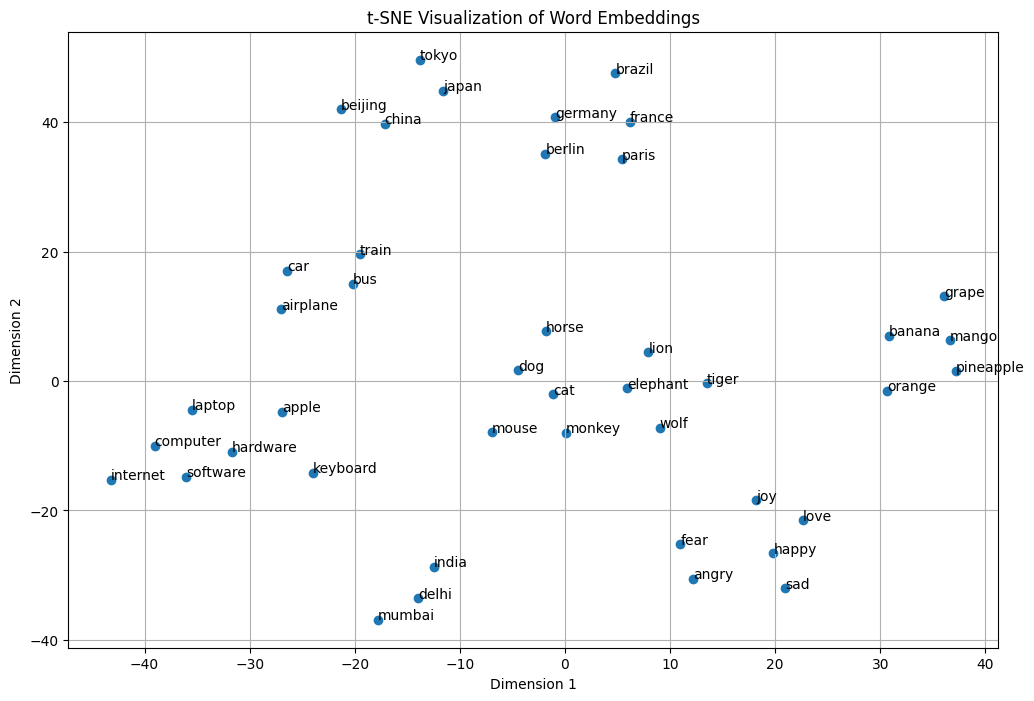

In [17]:


plt.figure(figsize=(12, 8))

x = reduced_vectors[:, 0]
y = reduced_vectors[:, 1]

plt.scatter(x, y)

# Annotate words
for i, word in enumerate(valid_words):
    plt.annotate(word, (x[i], y[i]))

plt.title("t-SNE Visualization of Word Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()
